# Bank Statement Processing and Transaction Categorization

This notebook documents the data checks, preprocessing, exploratory analysis, non-LLM classification, PDF extraction, and export workflow for the assessment. The labeled transaction data and sample statements are **synthetic demonstrations**. No accuracy figure here is a claim about real bank statements.

Run the cells from the project root after installing `requirements.txt`. The upload interface is in `app.py`.

## 1. Setup and data source

Extract the submission ZIP before opening this notebook. Keep `bank_statement_assessment.ipynb`, `bank_statement.py`, and `data/` in the same project folder. The setup cell finds that folder from Jupyter's working directory; if Jupyter starts elsewhere, set `PROJECT_DIR` to the extracted folder manually.

`data/transactions_labeled.csv` contains 288 generated descriptions across 12 categories. Each merchant phrase has four channel variants (`POS`, `CARD`, `ONLINE`, `TXN`). `merchant_group` identifies the underlying phrase, which matters when splitting data for evaluation.

In [1]:
from pathlib import Path
import shutil
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedGroupKFold

# If Jupyter starts outside the extracted project, set this to its full folder path.
PROJECT_DIR = None
if PROJECT_DIR is None:
    working_dir = Path.cwd().resolve()
    candidates = [working_dir, working_dir / 'bank_statement_assessment']
    for parent in working_dir.parents:
        candidates.extend([parent, parent / 'bank_statement_assessment'])
    PROJECT_DIR = next((folder for folder in candidates
                        if (folder / 'bank_statement.py').is_file()
                        and (folder / 'data' / 'transactions_labeled.csv').is_file()), None)
if PROJECT_DIR is None:
    raise FileNotFoundError(
        f'Project files were not found from {Path.cwd()}. Extract the ZIP, open '
        'the notebook from the project folder, or set PROJECT_DIR above.'
    )
PROJECT_DIR = Path(PROJECT_DIR).resolve()
sys.path.insert(0, str(PROJECT_DIR))
print('Project folder:', PROJECT_DIR)

from bank_statement import (
    DEFAULT_MIN_CONFIDENCE,
    classify_transactions,
    export_data,
    normalize_description,
    process_pdf,
    train_classifier,
)

DATA = PROJECT_DIR / 'data'
OUTPUT = PROJECT_DIR / 'outputs'
OUTPUT.mkdir(exist_ok=True)
raw = pd.read_csv(DATA / 'transactions_labeled.csv')
print('Shape:', raw.shape)
display(raw.head())

Project folder: D:\ML project


Shape: (288, 3)


,description,category,merchant_group
0,POS Acme payroll,Salary,Acme payroll
1,CARD Acme payroll,Salary,Acme payroll
2,ONLINE Acme payroll,Salary,Acme payroll
3,TXN Acme payroll,Salary,Acme payroll
4,POS Northstar salary,Salary,Northstar salary


## 2. Inspect the data with Pandas

Start with the raw CSV. Check its columns, data types, missing values, duplicates, and label consistency. `merchant_group` is the underlying merchant phrase; rows in one group must share a label. These checks come before changing or splitting the data.

In [2]:
required = {'description', 'category', 'merchant_group'}
assert required.issubset(raw.columns), f'Missing columns: {required - set(raw.columns)}'
print('Data types:')
display(raw.dtypes.to_frame('dtype'))
audit = pd.DataFrame({
    'missing': raw.isna().sum(),
    'unique_values': raw.nunique(dropna=True),
})
display(audit)
print('Duplicate description/category rows:', raw.duplicated(['description', 'category']).sum())
print('Merchant phrases with conflicting labels:',
      (raw.groupby('merchant_group')['category'].nunique() > 1).sum())

Data types:


,dtype
description,str
category,str
merchant_group,str


,missing,unique_values
description,0,288
category,0,12
merchant_group,0,72


Duplicate description/category rows: 0
Merchant phrases with conflicting labels: 0


### Prepare the text and labels

Remove rows without the fields needed for training, trim spaces, collapse repeated whitespace, and remove duplicate description/category pairs. Keep the original `description` for display; `normalize_description` also strips channel prefixes and long numeric IDs for the text model. The same normalization is used by the application.

In [3]:
labeled = raw.dropna(subset=['description', 'category', 'merchant_group']).copy()
for column in ['description', 'category', 'merchant_group']:
    labeled[column] = labeled[column].astype(str).str.strip().str.replace(r'\s+', ' ', regex=True)
labeled = labeled[(labeled['description'] != '') & (labeled['category'] != '')]
labeled = labeled.drop_duplicates(['description', 'category']).reset_index(drop=True)
labeled['description_clean'] = labeled['description'].map(normalize_description)
print('Rows before:', len(raw), '| Rows after:', len(labeled), '| Categories:', labeled['category'].nunique())
display(labeled[['description', 'description_clean', 'category']].head(8))

Rows before: 288 | Rows after: 288 | Categories: 12


,description,description_clean,category
0,POS Acme payroll,ACME PAYROLL,Salary
1,CARD Acme payroll,ACME PAYROLL,Salary
2,ONLINE Acme payroll,ACME PAYROLL,Salary
3,TXN Acme payroll,ACME PAYROLL,Salary
4,POS Northstar salary,NORTHSTAR SALARY,Salary
5,CARD Northstar salary,NORTHSTAR SALARY,Salary
6,ONLINE Northstar salary,NORTHSTAR SALARY,Salary
7,TXN Northstar salary,NORTHSTAR SALARY,Salary


## 3. Explore the prepared data

Use `value_counts`, string operations, and `groupby` to see class balance, text length, and channel variants. Each merchant phrase occurs with four channel prefixes. Those near-duplicates must stay together when we split the data.

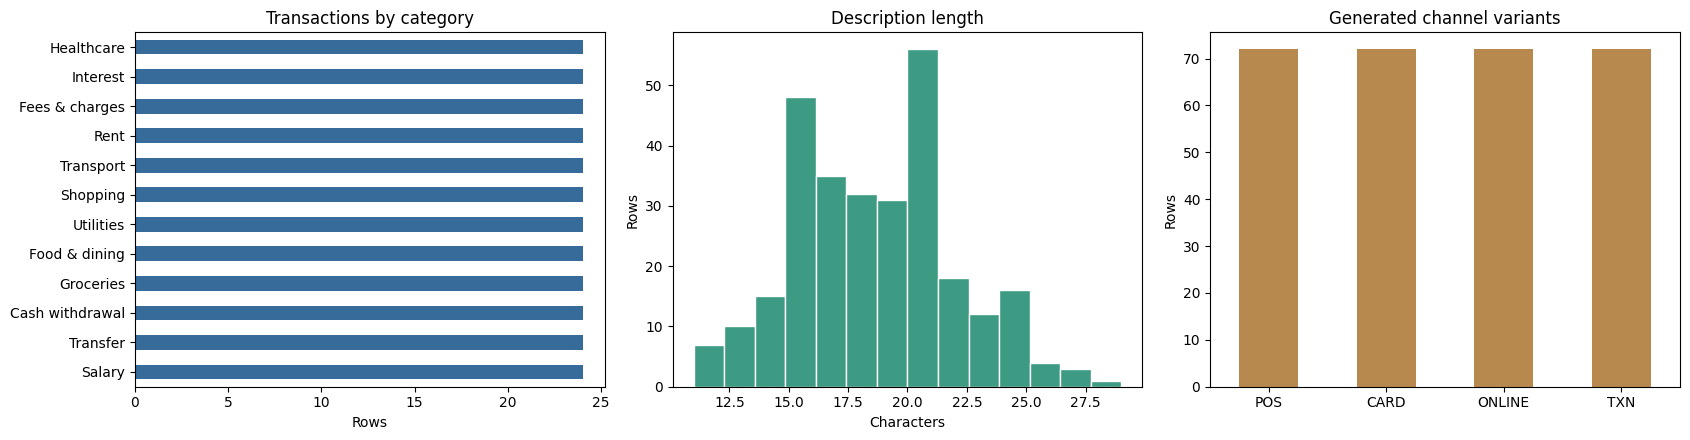

,description,description_clean
category,,
Cash withdrawal,POS ATM cash withdrawal,ATM CASH WITHDRAWAL
Fees & charges,POS bank charge,BANK CHARGE
Food & dining,POS Cafe Mosaic,CAFE MOSAIC
Groceries,POS Freshmart grocery,FRESHMART GROCERY
Healthcare,POS pharmacy purchase,PHARMACY PURCHASE
Interest,POS interest credit,INTEREST CREDIT
Rent,POS monthly rent,MONTHLY RENT
Salary,POS Acme payroll,ACME PAYROLL
Shopping,POS Amazon marketplace,AMAZON MARKETPLACE


In [4]:
category_counts = labeled['category'].value_counts().sort_values()
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
category_counts.plot.barh(ax=axes[0], color='#376b9a')
axes[0].set(title='Transactions by category', xlabel='Rows', ylabel='')

labeled['description_length'] = labeled['description'].str.len()
axes[1].hist(labeled['description_length'], bins=14, color='#3d9a83', edgecolor='white')
axes[1].set(title='Description length', xlabel='Characters', ylabel='Rows')

labeled['channel'] = labeled['description'].str.extract(r'^(POS|CARD|ONLINE|TXN)\b', expand=False).fillna('Other')
labeled['channel'].value_counts().plot.bar(ax=axes[2], color='#b8894e', rot=0)
axes[2].set(title='Generated channel variants', xlabel='', ylabel='Rows')
plt.tight_layout()
plt.show()
display(labeled.groupby('category', sort=True)[['description', 'description_clean']].first())

### What the distribution shows

The table summarizes rows, distinct merchant phrases, and description length per category. Similar counts reflect how this demonstration dataset was generated; they do not establish that real statements are balanced.

In [5]:
category_summary = labeled.groupby('category').agg(
    transactions=('description', 'size'),
    merchant_phrases=('merchant_group', 'nunique'),
    mean_description_length=('description_length', 'mean'),
).round(1)
display(category_summary)
print('Rows per merchant phrase:')
display(labeled.groupby('merchant_group').size().value_counts().sort_index().rename('merchant_phrases').to_frame())

,transactions,merchant_phrases,mean_description_length
category,,,
Cash withdrawal,24,6,19.0
Fees & charges,24,6,16.2
Food & dining,24,6,17.7
Groceries,24,6,22.8
Healthcare,24,6,19.0
Interest,24,6,19.5
Rent,24,6,18.8
Salary,24,6,18.8
Shopping,24,6,19.7


Rows per merchant phrase:


,merchant_phrases
4,72


## 4. Split by merchant phrase

Hold out two entire merchant phrases per category, including every channel variant. This leaves 192 training and 96 test rows. The test set checks unfamiliar phrases, while the training set alone determines the text vocabulary and model weights. The fixed sorted-phrase split is reproducible, but it is only one split of synthetic data.

In [6]:
held_out = set()
for category, subset in labeled.groupby('category'):
    held_out.update(sorted(subset['merchant_group'].unique())[-2:])
test_mask = labeled['merchant_group'].isin(held_out)
train, test = labeled.loc[~test_mask].copy(), labeled.loc[test_mask].copy()
assert set(train['merchant_group']).isdisjoint(test['merchant_group'])
print('Training rows:', len(train), '| Test rows:', len(test))
display(pd.concat({
    'train': train['category'].value_counts(),
    'test': test['category'].value_counts(),
}, axis=1).fillna(0).astype(int).sort_index())

Training rows: 192 | Test rows: 96


,train,test
category,,
Cash withdrawal,16,8
Fees & charges,16,8
Food & dining,16,8
Groceries,16,8
Healthcare,16,8
Interest,16,8
Rent,16,8
Salary,16,8
Shopping,16,8


## 5. Build and fit the ML pipeline

The pipeline has two fitted steps:

1. **Character TF-IDF:** convert normalized descriptions into weighted 3?5 character sequences. Character sequences tolerate spelling and spacing variations in merchant names.
2. **Logistic regression:** learn a score for each of the 12 categories. Balanced class weights are included in the application model.

`fit` sees only `train`. Calling `predict` on `test` later applies the same fitted TF-IDF transformation without learning from test descriptions. The settings match `train_classifier` in `bank_statement.py`, which the app uses.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

evaluation_model = make_pipeline(
    TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=1,
                    preprocessor=normalize_description),
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
)
evaluation_model.fit(train['description'], train['category'])
text_features = evaluation_model.named_steps['tfidfvectorizer'].transform(train['description'])
print('Training rows:', text_features.shape[0])
print('Learned TF-IDF features:', text_features.shape[1])
print('Feature matrix type:', type(text_features).__name__)
display(train[['description', 'description_clean', 'category']].head(5))

Training rows: 192
Learned TF-IDF features: 955
Feature matrix type: csr_matrix


,description,description_clean,category
0,POS Acme payroll,ACME PAYROLL,Salary
1,CARD Acme payroll,ACME PAYROLL,Salary
2,ONLINE Acme payroll,ACME PAYROLL,Salary
3,TXN Acme payroll,ACME PAYROLL,Salary
4,POS Northstar salary,NORTHSTAR SALARY,Salary


### Evaluate on unseen merchant phrases

First compare with a simple majority-class baseline. Then inspect accuracy, per-category precision/recall/F1, a confusion matrix, and examples of wrong predictions. The following scorecard also reports multiclass ROC AUC on this same 96-row holdout.

Majority-class baseline accuracy: 0.083


ML-only holdout accuracy: 0.625
                 precision    recall  f1-score   support

Cash withdrawal       0.67      1.00      0.80         8
 Fees & charges       1.00      1.00      1.00         8
  Food & dining       0.00      0.00      0.00         8
      Groceries       1.00      0.50      0.67         8
     Healthcare       0.00      0.00      0.00         8
       Interest       1.00      1.00      1.00         8
           Rent       0.40      1.00      0.57         8
         Salary       1.00      0.50      0.67         8
       Shopping       0.33      0.50      0.40         8
       Transfer       1.00      1.00      1.00         8
      Transport       1.00      0.50      0.67         8
      Utilities       0.50      0.50      0.50         8

       accuracy                           0.62        96
      macro avg       0.66      0.62      0.61        96
   weighted avg       0.66      0.62      0.61        96



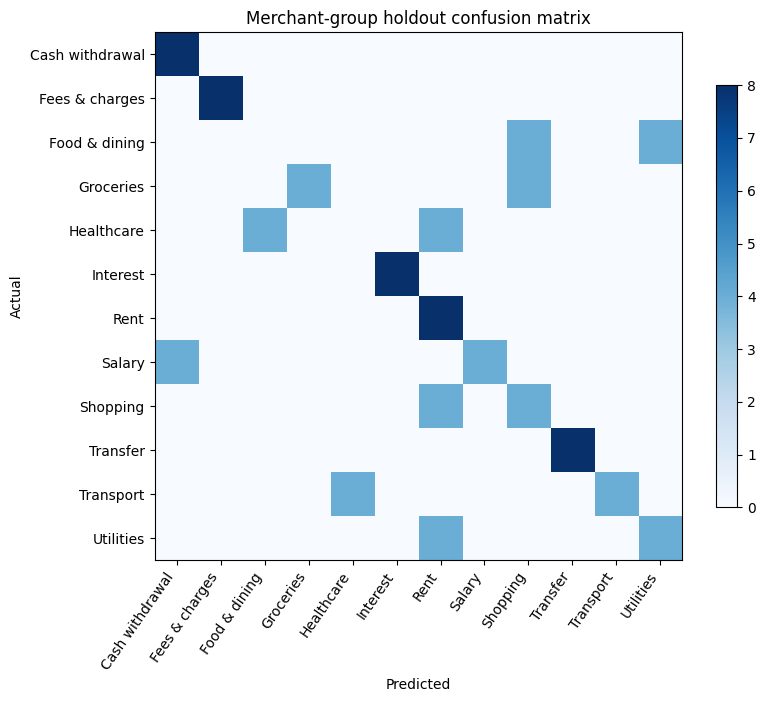

,description,category,predicted
8,POS Orbit wages,Salary,Cash withdrawal
9,CARD Orbit wages,Salary,Cash withdrawal
10,ONLINE Orbit wages,Salary,Cash withdrawal
11,TXN Orbit wages,Salary,Cash withdrawal
80,POS supermarket purchase,Groceries,Shopping
81,CARD supermarket purchase,Groceries,Shopping
82,ONLINE supermarket purchase,Groceries,Shopping
83,TXN supermarket purchase,Groceries,Shopping
108,POS restaurant bill,Food & dining,Utilities
109,CARD restaurant bill,Food & dining,Utilities


In [8]:
majority_category = train['category'].mode().iloc[0]
baseline_accuracy = (test['category'] == majority_category).mean()
print('Majority-class baseline accuracy:', round(baseline_accuracy, 3))

predicted = evaluation_model.predict(test['description'])
print('ML-only holdout accuracy:', round(accuracy_score(test['category'], predicted), 3))
print(classification_report(test['category'], predicted, zero_division=0))

labels = sorted(labeled['category'].unique())
matrix = confusion_matrix(test['category'], predicted, labels=labels)
fig, ax = plt.subplots(figsize=(8.5, 7))
image = ax.imshow(matrix, cmap='Blues')
ax.set(xticks=range(len(labels)), yticks=range(len(labels)),
       xticklabels=labels, yticklabels=labels,
       xlabel='Predicted', ylabel='Actual', title='Merchant-group holdout confusion matrix')
plt.setp(ax.get_xticklabels(), rotation=55, ha='right')
fig.colorbar(image, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

errors = test.loc[test['category'].to_numpy() != predicted, ['description', 'category']].copy()
errors['predicted'] = predicted[test['category'].to_numpy() != predicted]
display(errors.drop_duplicates(['description', 'category']).head(20))

### Individual predictions

The model returns a category and the largest class probability for each description. These probabilities rank model confidence on this synthetic set; they have not been calibrated on real statements.

In [9]:
preview = test[['description', 'category']].head(8).reset_index(drop=True).copy()
preview['predicted'] = evaluation_model.predict(preview['description'])
preview['confidence'] = evaluation_model.predict_proba(preview['description']).max(axis=1).round(3)
display(preview.rename(columns={'category': 'actual'}))

,description,actual,predicted,confidence
0,POS Orbit wages,Salary,Cash withdrawal,0.157
1,CARD Orbit wages,Salary,Cash withdrawal,0.157
2,ONLINE Orbit wages,Salary,Cash withdrawal,0.157
3,TXN Orbit wages,Salary,Cash withdrawal,0.157
4,POS Studio salary,Salary,Salary,0.256
5,CARD Studio salary,Salary,Salary,0.256
6,ONLINE Studio salary,Salary,Salary,0.256
7,TXN Studio salary,Salary,Salary,0.256


### Reading the metrics

- **Accuracy:** the share assigned the correct final category.
- **Precision:** when the model predicts a category, how often that prediction is correct.
- **Recall:** how much of a true category the model recovers.
- **F1:** balances precision and recall. Macro averages give every category equal weight; weighted averages account for the number of rows per category.
- **ROC AUC (one-vs-rest):** how well the model ranks each category above the other 11 using predicted probabilities, across thresholds. It is a ranking measure, so it can be higher than final-label accuracy. The micro ROC pools all category decisions.

All values below come from the **ML-only model on held-out merchant phrases**. A score of 1.0 is perfect. The dashed ROC diagonal is random ranking (AUC 0.5).

Macro and weighted averages are equal in this holdout because each category contributes eight rows.

Model-only metrics | synthetic merchant holdout | n = 96


,Metric,Value,Interpretation
0,Accuracy,0.625,Correct final labels / 96 rows
1,Precision (macro),0.658,Mean precision across 12 categories
2,Recall (macro),0.625,Mean recall across 12 categories
3,F1 (macro),0.606,Mean F1 across 12 categories
4,Precision (weighted),0.658,Precision weighted by category support
5,Recall (weighted),0.625,Recall weighted by category support
6,F1 (weighted),0.606,F1 weighted by category support
7,"ROC AUC (macro, OvR)",0.894,Mean one-vs-rest category AUC
8,"ROC AUC (weighted, OvR)",0.894,One-vs-rest AUC weighted by support
9,"ROC AUC (micro, OvR)",0.901,All one-vs-rest decisions pooled


Per-category model results


,precision,recall,f1-score,support,ROC AUC (OvR)
Cash withdrawal,0.667,1.0,0.800,8.0,1.000
Fees & charges,1.000,1.0,1.000,8.0,1.000
Food & dining,0.000,0.0,0.000,8.0,0.545
Groceries,1.000,0.5,0.667,8.0,1.000
Healthcare,0.000,0.0,0.000,8.0,0.477
Interest,1.000,1.0,1.000,8.0,1.000
Rent,0.400,1.0,0.571,8.0,0.977
Salary,1.000,0.5,0.667,8.0,0.909
Shopping,0.333,0.5,0.400,8.0,0.864
Transfer,1.000,1.0,1.000,8.0,1.000


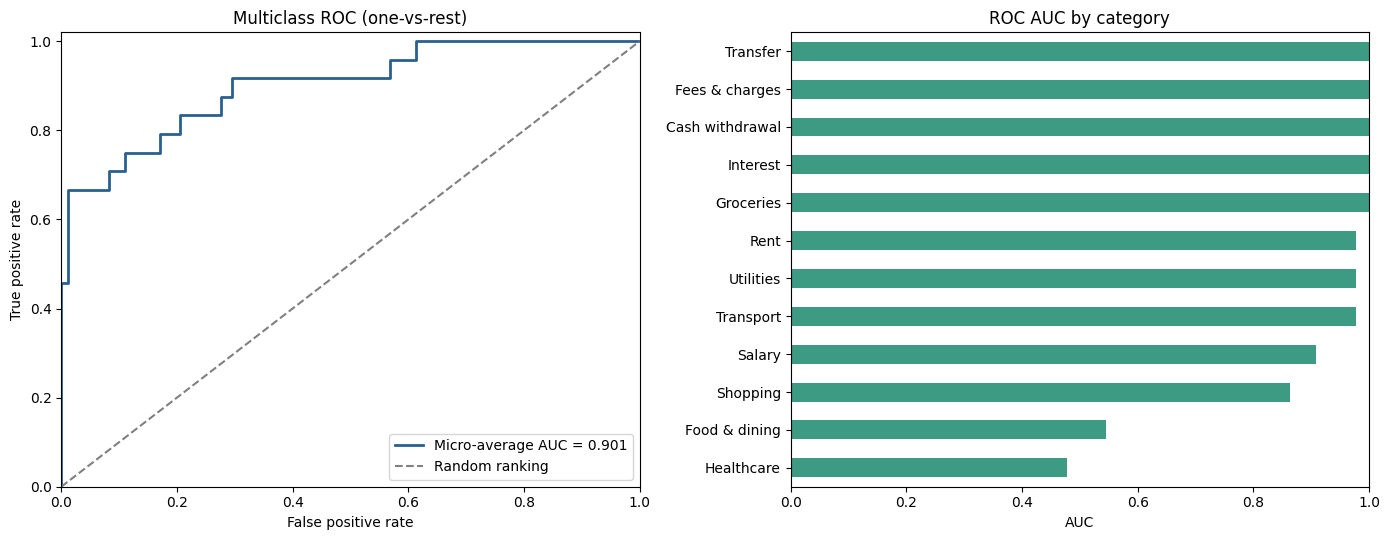

In [10]:
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

classes = evaluation_model.classes_
assert set(classes) == set(test['category']), 'ROC AUC needs every class represented in the holdout'
probabilities = evaluation_model.predict_proba(test['description'])
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    test['category'], predicted, average='macro', zero_division=0
)
weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
    test['category'], predicted, average='weighted', zero_division=0
)
auc_macro = roc_auc_score(test['category'], probabilities, multi_class='ovr', average='macro', labels=classes)
auc_weighted = roc_auc_score(test['category'], probabilities, multi_class='ovr', average='weighted', labels=classes)
one_hot = label_binarize(test['category'], classes=classes)
fpr, tpr, _ = roc_curve(one_hot.ravel(), probabilities.ravel())
auc_micro = auc(fpr, tpr)

scorecard = pd.DataFrame([
    ['Accuracy', accuracy_score(test['category'], predicted), 'Correct final labels / 96 rows'],
    ['Precision (macro)', macro_p, 'Mean precision across 12 categories'],
    ['Recall (macro)', macro_r, 'Mean recall across 12 categories'],
    ['F1 (macro)', macro_f1, 'Mean F1 across 12 categories'],
    ['Precision (weighted)', weighted_p, 'Precision weighted by category support'],
    ['Recall (weighted)', weighted_r, 'Recall weighted by category support'],
    ['F1 (weighted)', weighted_f1, 'F1 weighted by category support'],
    ['ROC AUC (macro, OvR)', auc_macro, 'Mean one-vs-rest category AUC'],
    ['ROC AUC (weighted, OvR)', auc_weighted, 'One-vs-rest AUC weighted by support'],
    ['ROC AUC (micro, OvR)', auc_micro, 'All one-vs-rest decisions pooled'],
], columns=['Metric', 'Value', 'Interpretation'])
print('Model-only metrics | synthetic merchant holdout | n =', len(test))
display(scorecard.round({'Value': 3}))

report = classification_report(test['category'], predicted, output_dict=True, zero_division=0)
per_category = pd.DataFrame(report).T.loc[list(classes), ['precision', 'recall', 'f1-score', 'support']]
per_category['ROC AUC (OvR)'] = [
    roc_auc_score((test['category'] == category).astype(int), probabilities[:, i])
    for i, category in enumerate(classes)
]
print('Per-category model results')
display(per_category.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].plot(fpr, tpr, color='#286090', lw=2, label=f'Micro-average AUC = {auc_micro:.3f}')
axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Random ranking')
axes[0].set(xlabel='False positive rate', ylabel='True positive rate',
            title='Multiclass ROC (one-vs-rest)', xlim=(0, 1), ylim=(0, 1.02))
axes[0].legend(loc='lower right')
per_category['ROC AUC (OvR)'].sort_values().plot.barh(ax=axes[1], color='#3d9a83')
axes[1].set(xlabel='AUC', ylabel='', title='ROC AUC by category', xlim=(0, 1))
plt.tight_layout()
plt.show()

## 6. Confidence and review tradeoff

An uncertain model prediction is more useful as `Review` than as a confident-looking wrong label. Four-fold cross-validation keeps merchant groups intact and evaluates several cutoffs on training data only. `auto_accuracy` measures correctness **among automatic ML predictions**; `auto_coverage` is their share of all rows. The values are descriptive, not calibrated probabilities for real data.

In [11]:
cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)
validation_rows = []
for fit_idx, val_idx in cv.split(train['description'], train['category'], train['merchant_group']):
    fold_model = train_classifier(train.iloc[fit_idx])
    probabilities = fold_model.predict_proba(train.iloc[val_idx]['description'])
    fold_pred = fold_model.classes_[probabilities.argmax(axis=1)]
    for confidence, prediction, actual in zip(probabilities.max(axis=1), fold_pred, train.iloc[val_idx]['category']):
        validation_rows.append({'confidence': confidence, 'correct': prediction == actual})
validation = pd.DataFrame(validation_rows)
threshold_rows = []
for threshold in (0.20, 0.30, 0.40, 0.50):
    automatic = validation.loc[validation['confidence'] >= threshold]
    threshold_rows.append({
        'threshold': threshold,
        'auto_coverage': len(automatic) / len(validation),
        'auto_accuracy': automatic['correct'].mean(),
    })
display(pd.DataFrame(threshold_rows).round(3))

holdout_probabilities = evaluation_model.predict_proba(test['description'])
holdout_pred = evaluation_model.classes_[holdout_probabilities.argmax(axis=1)]
auto_mask = holdout_probabilities.max(axis=1) >= DEFAULT_MIN_CONFIDENCE
print('Selected cutoff:', DEFAULT_MIN_CONFIDENCE)
print('Holdout automatic coverage:', round(auto_mask.mean(), 3))
print('Holdout automatic ML accuracy:', round(accuracy_score(test['category'].to_numpy()[auto_mask], holdout_pred[auto_mask]), 3))
print('Sent to review:', int((~auto_mask).sum()), 'of', len(test))

,threshold,auto_coverage,auto_accuracy
0,0.2,0.771,0.838
1,0.3,0.542,0.885
2,0.4,0.438,0.905
3,0.5,0.292,0.929


Selected cutoff: 0.4
Holdout automatic coverage: 0.5
Holdout automatic ML accuracy: 0.917
Sent to review: 48 of 96


## 7. Full classification policy

The application uses specific, inspectable rules for descriptions with clear merchant/category terms, then the ML model for the remainder. A payment rail such as `UPI` alone does not determine the category. The holdout below is fully matched by the rules, so its combined score is a **functional check**, not an independent estimate of future accuracy. The separate challenge CSV is a hand-written regression set used during rule development.

In [12]:
hybrid = classify_transactions(test[['description']], evaluation_model)
print('Combined rule + ML holdout accuracy:', round(accuracy_score(test['category'], hybrid['category']), 3))
print('Methods:', hybrid['classification_method'].value_counts().to_dict())

model = train_classifier(labeled)
challenge = pd.read_csv(DATA / 'challenge_transactions.csv')
challenge_result = classify_transactions(challenge[['description']], model)
print('Hand-written regression-set accuracy:', round(accuracy_score(challenge['category'], challenge_result['category']), 3))
display(pd.DataFrame({
    'description': challenge['description'],
    'expected': challenge['category'],
    'predicted': challenge_result['category'],
    'method': challenge_result['classification_method'],
}))

Combined rule + ML holdout accuracy: 1.0
Methods: {'rule': 96}
Hand-written regression-set accuracy: 1.0


,description,expected,predicted,method
0,NEFT Acme payroll salary,Salary,Salary,rule
1,IMPS monthly wages payout,Salary,Salary,rule
2,UPI to Rohan,Transfer,Transfer,rule
3,IMPS transfer to sister,Transfer,Transfer,rule
4,NEFT to Ajay,Transfer,Transfer,rule
5,ATM cash withdrawal terminal,Cash withdrawal,Cash withdrawal,rule
6,CASH WDL branch,Cash withdrawal,Cash withdrawal,rule
7,UPI Freshmart grocery,Groceries,Groceries,rule
8,POS supermarket milk,Groceries,Groceries,rule
9,Bigbasket card purchase,Groceries,Groceries,rule


## 8. PDF extraction and validation

Two small generated statements demonstrate separate debit/credit columns and a signed amount column. The extraction routine detects text pages, captures account details and rows, and flags balance discontinuities. The examples use synthetic account details.

In [13]:
processed = {}
for filename in ('sample_statement_split.pdf', 'sample_statement_signed.pdf'):
    extracted = process_pdf(DATA / filename)
    classified = classify_transactions(extracted.transactions, model)
    processed[filename] = classified
    print(filename, '| pages:', extracted.page_types, '| rows:', len(classified))
    print('Account:', extracted.account)
    print('Warnings:', extracted.warnings)
    display(classified[['date', 'description', 'debit', 'credit', 'balance', 'category', 'balance_check']])

sample_statement_split.pdf

 | pages: ['text'] | rows: 8
Account: {'account_holder': 'Asha Rao', 'account_number': '123456789012', 'ifsc': 'DEMO0123456'}
Warnings: []


,date,description,debit,credit,balance,category,balance_check
0,2026-04-01,Opening salary credit,NaN,50000.0,50000.0,Salary,
1,2026-04-02,Freshmart grocery,1250.0,NaN,48750.0,Groceries,
2,2026-04-03,UPI transfer to friend,2000.0,NaN,46750.0,Transfer,
3,2026-04-04,Interest credit,NaN,25.0,46775.0,Interest,
4,2026-04-05,Electricity bill,875.0,NaN,45900.0,Utilities,
5,2026-04-06,ATM cash withdrawal,3000.0,NaN,42900.0,Cash withdrawal,
6,2026-04-07,Cafe Mosaic,450.0,NaN,42450.0,Food & dining,
7,2026-04-08,Refund from vendor,NaN,500.0,42950.0,Review,


sample_statement_signed.pdf | pages: ['text'] | rows: 6
Account: {'account_holder': 'Asha Rao', 'account_number': '123456789012', 'ifsc': 'DEMO0123456'}
Warnings: []


,date,description,debit,credit,balance,category,balance_check
0,2026-05-01,Northstar salary,NaN,60000.0,60000.0,Salary,
1,2026-05-02,Monthly rent,15000.0,NaN,45000.0,Rent,
2,2026-05-03,Uber ride,420.0,NaN,44580.0,Transport,
3,2026-05-04,Amazon marketplace,2100.0,NaN,42480.0,Shopping,
4,2026-05-05,Medical store purchase,650.0,NaN,41830.0,Healthcare,
5,2026-05-06,Bank service fee,50.0,NaN,41780.0,Fees & charges,


### Image-only PDF

The third example is a rasterized PDF with no extractable text. OCR requires the Tesseract executable in addition to the Python package. Every OCR page is flagged for review because a visually plausible amount may still be wrong.

In [14]:
if shutil.which('tesseract'):
    scanned = process_pdf(DATA / 'sample_statement_scanned.pdf')
    print('Page types:', scanned.page_types, '| rows:', len(scanned.transactions))
    print('Warnings:', scanned.warnings)
    display(classify_transactions(scanned.transactions, model))
else:
    print('Tesseract is not installed here; install it and rerun this cell to test image extraction.')

Tesseract is not installed here; install it and rerun this cell to test image extraction.


## 9. Export

The structured file keeps both the extracted fields and the classification result. The app allows a reviewer to edit a category before downloading CSV or Excel.

In [15]:
final = pd.concat(processed.values(), ignore_index=True)
csv_path = export_data(final, OUTPUT / 'classified_transactions.csv')
xlsx_path = export_data(final, OUTPUT / 'classified_transactions.xlsx')
print('Wrote:', csv_path, 'and', xlsx_path)
print('Rows:', len(final), '| Balance flags:', (final['balance_check'] == 'REVIEW').sum(),
      '| Categories sent to review:', (final['category'] == 'Review').sum())

Wrote: D:\ML project\outputs\classified_transactions.csv and D:\ML project\outputs\classified_transactions.xlsx
Rows: 14 | Balance flags: 0 | Categories sent to review: 1


## 10. Findings and limits

- The PDF parser recovered all 14 rows from the two generated text statements, with no balance warnings. This does not establish extraction accuracy across banks.
- The ML-only merchant-group holdout remains difficult because some held-out phrases contain category words absent from training. The review threshold reduces wrong automatic predictions at the cost of coverage.
- The combined rule + ML result and the hand-written challenge result are checks of this prototype's behavior. They are not independent real-world benchmarks.
- For a deployment, collect consented and annotated statement samples from target banks, measure field-level extraction accuracy and category precision/recall, calibrate review thresholds, test OCR on real scans, and apply access and retention controls.
- On the synthetic merchant holdout, model-only accuracy is 0.625, macro F1 is 0.606, and macro one-vs-rest ROC AUC is 0.894. ROC AUC summarizes ranking quality; the confusion matrix and F1 show remaining final-label errors.